### PTB-XL Exploratory Data Analysis
#### CardioFusion-XAI — ECG Modality

This notebook performs a reproducible EDA of the PTB-XL ECG dataset.

Objectives:
- Understand dataset structure and demographics
- Correctly map SCP codes to diagnostic superclasses
- Analyze diagnostic and rhythm label distributions
- Analyze multi-label co-occurrence
- Audit official PTB-XL train/validation/test folds
- Check patient-level leakage across folds
- Inspect ECG signal shape, sampling frequency and leads
- Analyze annotation and quality metadata
- Identify class imbalance and rare labels
- Save EDA artifacts for reproducibility

Important:
- `scp_codes`, `report`, and other annotation/metadata fields are used only
  for dataset analysis and target construction.
- They are NOT model inputs for the ECG-only predictor.

In [1]:
from pathlib import Path
import ast
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "ecg" / "ptbxl"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "ptbxl"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DATABASE_FILE = DATA_DIR / "ptbxl_database.csv"
SCP_FILE = DATA_DIR / "scp_statements.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset dir  :", DATA_DIR)
print("Artifact dir :", ARTIFACT_DIR)

Project root : D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service
Dataset dir  : D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\ecg\ptbxl
Artifact dir : D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\ptbxl


In [4]:
required_files = {
    "PTB-XL database": DATABASE_FILE,
    "SCP statements": SCP_FILE,
}

for name, path in required_files.items():
    print(f"{name:<20}: {path.exists()}")

missing = [str(path) for path in required_files.values() if not path.exists()]

if missing:
    raise FileNotFoundError(
        "The following required files are missing:\n" +
        "\n".join(missing)
    )

print("\nAll required PTB-XL files are present.")

PTB-XL database     : True
SCP statements      : True

All required PTB-XL files are present.


In [5]:
ptbxl = pd.read_csv(DATABASE_FILE, index_col=0)
scp = pd.read_csv(SCP_FILE, index_col=0)

print(f"PTB-XL records : {len(ptbxl):,}")
print(f"PTB-XL columns : {ptbxl.shape[1]:,}")
print(f"SCP statements : {len(scp):,}")

display(ptbxl.head())

PTB-XL records : 21,837
PTB-XL columns : 27
SCP statements : 71


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [6]:
schema = pd.DataFrame({
    "column": ptbxl.columns,
    "dtype": ptbxl.dtypes.astype(str).values,
    "missing": ptbxl.isna().sum().values,
    "missing_pct": (
        ptbxl.isna().mean().values * 100
    ).round(2),
    "unique": [
        ptbxl[col].nunique(dropna=True)
        for col in ptbxl.columns
    ],
})

display(schema)

schema.to_csv(
    ARTIFACT_DIR / "schema_summary.csv",
    index=False
)

,column,dtype,missing,missing_pct,unique
0,patient_id,float64,0,0.00,18885
1,age,float64,89,0.41,94
2,sex,int64,0,0.00,2
3,height,float64,14854,68.02,77
4,weight,float64,12408,56.82,127
5,nurse,float64,1509,6.91,12
6,site,float64,18,0.08,51
7,device,object,0,0.00,11
8,recording_date,object,0,0.00,21813
9,report,object,0,0.00,9883


In [6]:
patient_count = ptbxl["patient_id"].nunique()

duplicate_rows = ptbxl.duplicated().sum()

print(f"ECG recordings : {len(ptbxl):,}")
print(f"Unique patients: {patient_count:,}")
print(f"Duplicate rows : {duplicate_rows:,}")

if "age" in ptbxl.columns:
    print(f"\nAge range      : {ptbxl['age'].min()} - {ptbxl['age'].max()}")

if "sex" in ptbxl.columns:
    print("\nSex distribution:")
    display(ptbxl["sex"].value_counts(dropna=False).to_frame("count"))

ECG recordings : 21,837
Unique patients: 18,885
Duplicate rows : 0

Age range      : 2.0 - 95.0

Sex distribution:


,count
sex,
0,11379
1,10458


In [7]:
num_records = len(ptbxl)
num_patients = ptbxl["patient_id"].nunique()
duplicate_rows = int(ptbxl.duplicated().sum())

print(f"ECG recordings : {num_records:,}")
print(f"Unique patients: {num_patients:,}")
print(f"Duplicate rows : {duplicate_rows:,}")

records_per_patient = (
    ptbxl.groupby("patient_id")
    .size()
    .sort_values(ascending=False)
)

print("\nECGs per patient:")
display(
    records_per_patient
    .describe()
    .to_frame("value")
)

print("\nPatients with more than one ECG:")
print(
    int((records_per_patient > 1).sum()),
    "patients"
)

ECG recordings : 21,837
Unique patients: 18,885
Duplicate rows : 0

ECGs per patient:


,value
count,18885.000000
mean,1.156315
std,0.524680
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,10.000000



Patients with more than one ECG:
2127 patients


In [8]:
demographic_summary = pd.DataFrame(index=["count", "missing", "mean", "std", "min", "median", "max"])

for column in ["age", "height", "weight"]:
    if column in ptbxl.columns:
        values = pd.to_numeric(ptbxl[column], errors="coerce")

        demographic_summary.loc["count", column] = values.notna().sum()
        demographic_summary.loc["missing", column] = values.isna().sum()
        demographic_summary.loc["mean", column] = values.mean()
        demographic_summary.loc["std", column] = values.std()
        demographic_summary.loc["min", column] = values.min()
        demographic_summary.loc["median", column] = values.median()
        demographic_summary.loc["max", column] = values.max()

display(demographic_summary)

,age,height,weight
count,21748.000000,6983.000000,9429.000000
missing,89.000000,14854.000000,12408.000000
mean,59.836307,166.708292,70.997561
std,16.953125,10.864935,15.875146
min,2.000000,6.000000,5.000000
median,62.000000,166.000000,70.000000
max,95.000000,209.000000,250.000000


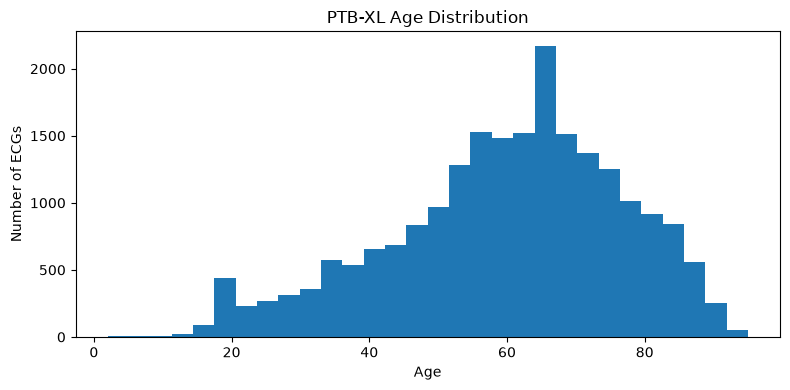

Age range: 2.0 - 95.0
Age median: 62.0


In [10]:
age = pd.to_numeric(ptbxl["age"], errors="coerce")

plt.figure(figsize=(8, 4))
plt.hist(age.dropna(), bins=30)
plt.xlabel("Age")
plt.ylabel("Number of ECGs")
plt.title("PTB-XL Age Distribution")
plt.tight_layout()
plt.show()

print(f"Age range: {age.min()} - {age.max()}")
print(f"Age median: {age.median():.1f}")

,count,percentage
sex,,
0,11379,52.11
1,10458,47.89


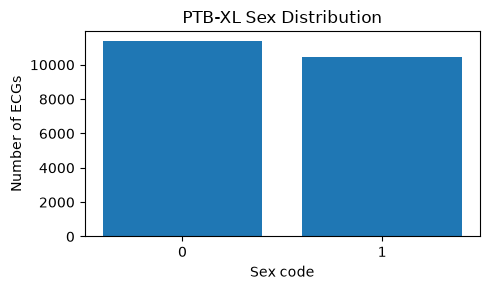

In [12]:
sex_counts = (
    ptbxl["sex"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("sex")
    .to_frame("count")
)

sex_counts["percentage"] = (
    sex_counts["count"] / len(ptbxl) * 100
).round(2)

display(sex_counts)

plt.figure(figsize=(5, 3))
plt.bar(
    sex_counts.index.astype(str),
    sex_counts["count"]
)
plt.xlabel("Sex code")
plt.ylabel("Number of ECGs")
plt.title("PTB-XL Sex Distribution")
plt.tight_layout()
plt.show()

sex_counts.to_csv(
    ARTIFACT_DIR / "sex_distribution.csv"
)

In [13]:
DIAGNOSTIC_LABELS = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
]

RHYTHM_LABELS = [
    "SR",
    "AFIB",
    "AFLT",
    "STACH",
    "SBRAD",
    "SARRH",
    "PSVT",
    "BIGU",
    "PACE",
]

print("Diagnostic labels:")
print(DIAGNOSTIC_LABELS)

print("\nRhythm labels:")
print(RHYTHM_LABELS)

Diagnostic labels:
['NORM', 'MI', 'STTC', 'CD', 'HYP']

Rhythm labels:
['SR', 'AFIB', 'AFLT', 'STACH', 'SBRAD', 'SARRH', 'PSVT', 'BIGU', 'PACE']


In [14]:
print("SCP statement columns:")
print(scp.columns.tolist())

display(scp.head(20))

SCP statement columns:
['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [15]:
def parse_scp_codes(value):
    """
    Convert the string representation of SCP annotations
    into a Python dictionary.
    """
    if pd.isna(value):
        return {}

    if isinstance(value, dict):
        return value

    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, dict):
            return parsed

    except (ValueError, SyntaxError, TypeError):
        pass

    return {}


ptbxl["scp_codes_parsed"] = (
    ptbxl["scp_codes"]
    .apply(parse_scp_codes)
)

print("Example parsed SCP annotation:")
print(ptbxl["scp_codes_parsed"].iloc[0])

Example parsed SCP annotation:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


In [16]:
empty_annotations = (
    ptbxl["scp_codes_parsed"]
    .apply(lambda x: len(x) == 0)
)

print("Empty parsed annotations:", int(empty_annotations.sum()))
print(
    "Percentage empty:",
    round(empty_annotations.mean() * 100, 4),
    "%"
)

if empty_annotations.any():
    display(
        ptbxl.loc[
            empty_annotations,
            ["ecg_id", "scp_codes"]
        ].head(20)
    )

Empty parsed annotations: 0
Percentage empty: 0.0 %


In [17]:
required_scp_columns = ["diagnostic", "diagnostic_class"]

missing_columns = [
    col for col in required_scp_columns
    if col not in scp.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns in scp_statements.csv: {missing_columns}"
    )

diagnostic_map = (
    scp.loc[
        (scp["diagnostic"] == 1) &
        (scp["diagnostic_class"].isin(DIAGNOSTIC_LABELS))
    ]["diagnostic_class"]
    .to_dict()
)

print(f"Diagnostic SCP mappings found: {len(diagnostic_map)}")

diagnostic_mapping_table = (
    pd.Series(diagnostic_map, name="diagnostic_class")
    .rename_axis("scp_code")
    .reset_index()
    .sort_values(["diagnostic_class", "scp_code"])
)

display(diagnostic_mapping_table)

Diagnostic SCP mappings found: 44


,scp_code,diagnostic_class
11,1AVB,CD
43,2AVB,CD
41,3AVB,CD
15,CLBBB,CD
14,CRBBB,CD
33,ILBBB,CD
10,IRBBB,CD
12,IVCD,CD
8,LAFB,CD
24,LPFB,CD


In [18]:
def get_diagnostic_labels(codes):
    """
    Map raw SCP codes to PTB-XL diagnostic superclass labels.
    """
    labels = set()

    for code in codes.keys():
        diagnostic_class = diagnostic_map.get(code)

        if diagnostic_class is not None:
            labels.add(diagnostic_class)

    return labels


ptbxl["diagnostic_labels"] = (
    ptbxl["scp_codes_parsed"]
    .apply(get_diagnostic_labels)
)

print("Example diagnostic labels:")
print(ptbxl["diagnostic_labels"].iloc[0])

Example diagnostic labels:
{'NORM'}


In [19]:
diagnostic_counts = pd.Series({
    label: int(
        ptbxl["diagnostic_labels"]
        .apply(lambda labels: label in labels)
        .sum()
    )
    for label in DIAGNOSTIC_LABELS
})

diagnostic_summary = (
    diagnostic_counts
    .rename("count")
    .to_frame()
)

diagnostic_summary["percentage"] = (
    diagnostic_summary["count"] / len(ptbxl) * 100
).round(2)

diagnostic_summary = diagnostic_summary.sort_values(
    "count",
    ascending=False
)

display(diagnostic_summary)

diagnostic_summary.to_csv(
    ARTIFACT_DIR / "diagnostic_summary.csv"
)

,count,percentage
NORM,9528,43.63
MI,5486,25.12
STTC,5250,24.04
CD,4907,22.47
HYP,2655,12.16


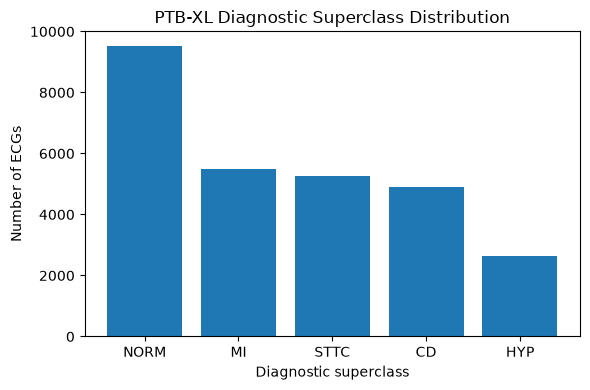

In [20]:
plt.figure(figsize=(6, 4))

plt.bar(
    diagnostic_summary.index,
    diagnostic_summary["count"]
)

plt.xlabel("Diagnostic superclass")
plt.ylabel("Number of ECGs")
plt.title("PTB-XL Diagnostic Superclass Distribution")
plt.tight_layout()
plt.show()

In [21]:
def get_rhythm_labels(codes):
    return {
        label
        for label in RHYTHM_LABELS
        if label in codes
    }


ptbxl["rhythm_labels"] = (
    ptbxl["scp_codes_parsed"]
    .apply(get_rhythm_labels)
)

In [22]:
rhythm_counts = pd.Series({
    label: int(
        ptbxl["rhythm_labels"]
        .apply(lambda labels: label in labels)
        .sum()
    )
    for label in RHYTHM_LABELS
})

rhythm_summary = (
    rhythm_counts
    .rename("count")
    .to_frame()
)

rhythm_summary["percentage"] = (
    rhythm_summary["count"] / len(ptbxl) * 100
).round(2)

rhythm_summary = rhythm_summary.sort_values(
    "count",
    ascending=False
)

display(rhythm_summary)

rhythm_summary.to_csv(
    ARTIFACT_DIR / "rhythm_summary.csv"
)

,count,percentage
SR,16782,76.85
AFIB,1514,6.93
STACH,826,3.78
SARRH,772,3.54
SBRAD,637,2.92
PACE,296,1.36
BIGU,82,0.38
AFLT,73,0.33
PSVT,24,0.11


In [23]:
ptbxl["scp_annotation_count"] = (
    ptbxl["scp_codes_parsed"]
    .apply(len)
)

print(
    "Average SCP annotations per ECG:",
    round(ptbxl["scp_annotation_count"].mean(), 2)
)

print(
    "Median SCP annotations per ECG:",
    ptbxl["scp_annotation_count"].median()
)

print(
    "Maximum SCP annotations on one ECG:",
    ptbxl["scp_annotation_count"].max()
)

Average SCP annotations per ECG: 2.8
Median SCP annotations per ECG: 2.0
Maximum SCP annotations on one ECG: 9


,ecg_count
scp_annotation_count,
1,705
2,11247
3,5114
4,2597
5,1254
6,597
7,253
8,63
9,7


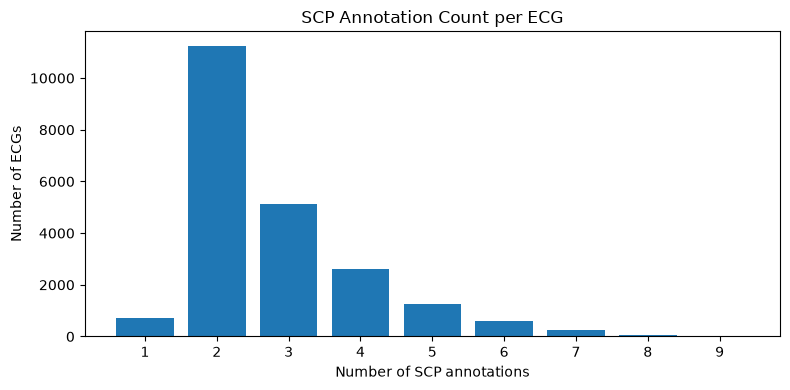

In [25]:
annotation_distribution = (
    ptbxl["scp_annotation_count"]
    .value_counts()
    .sort_index()
    .rename("ecg_count")
    .to_frame()
)

display(annotation_distribution)

plt.figure(figsize=(8, 4))

plt.bar(
    annotation_distribution.index.astype(str),
    annotation_distribution["ecg_count"]
)

plt.xlabel("Number of SCP annotations")
plt.ylabel("Number of ECGs")
plt.title("SCP Annotation Count per ECG")
plt.tight_layout()
plt.show()

In [26]:
diagnostic_cooccurrence = pd.DataFrame(
    0,
    index=DIAGNOSTIC_LABELS,
    columns=DIAGNOSTIC_LABELS,
    dtype=int
)

for labels in ptbxl["diagnostic_labels"]:
    labels = list(labels)

    for label_a in labels:
        for label_b in labels:
            diagnostic_cooccurrence.loc[
                label_a,
                label_b
            ] += 1

display(diagnostic_cooccurrence)

diagnostic_cooccurrence.to_csv(
    ARTIFACT_DIR / "diagnostic_cooccurrence.csv"
)

,NORM,MI,STTC,CD,HYP
NORM,9528,1,33,415,5
MI,1,5486,1345,1801,821
STTC,33,1345,5250,1069,1514
CD,415,1801,1069,4907,789
HYP,5,821,1514,789,2655


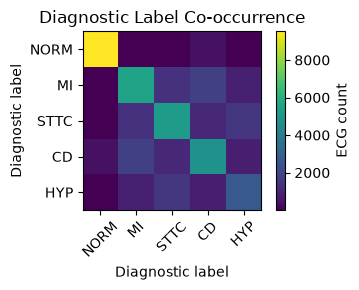

In [28]:
plt.figure(figsize=(4, 3))

plt.imshow(diagnostic_cooccurrence.values)

plt.xticks(
    range(len(DIAGNOSTIC_LABELS)),
    DIAGNOSTIC_LABELS,
    rotation=45
)

plt.yticks(
    range(len(DIAGNOSTIC_LABELS)),
    DIAGNOSTIC_LABELS
)

plt.xlabel("Diagnostic label")
plt.ylabel("Diagnostic label")
plt.title("Diagnostic Label Co-occurrence")

plt.colorbar(label="ECG count")

plt.tight_layout()
plt.show()

In [29]:
diagnostic_rhythm_cooccurrence = pd.DataFrame(
    0,
    index=DIAGNOSTIC_LABELS,
    columns=RHYTHM_LABELS,
    dtype=int
)

for _, row in ptbxl.iterrows():

    diagnostic_labels = row["diagnostic_labels"]
    rhythm_labels = row["rhythm_labels"]

    for diagnostic in diagnostic_labels:
        for rhythm in rhythm_labels:
            diagnostic_rhythm_cooccurrence.loc[
                diagnostic,
                rhythm
            ] += 1

display(diagnostic_rhythm_cooccurrence)

diagnostic_rhythm_cooccurrence.to_csv(
    ARTIFACT_DIR / "diagnostic_rhythm_cooccurrence.csv"
)

,SR,AFIB,AFLT,STACH,SBRAD,SARRH,PSVT,BIGU,PACE
NORM,8218,37,0,236,353,427,0,13,1
MI,3965,605,9,296,108,163,0,27,5
STTC,3495,908,15,267,112,138,8,22,4
CD,3594,455,13,240,136,148,1,21,4
HYP,1924,278,3,162,68,75,0,13,2


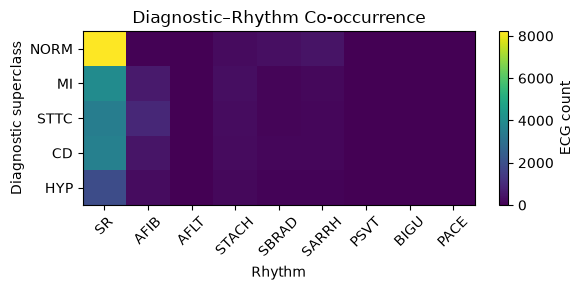

In [30]:
plt.figure(figsize=(6, 3))

plt.imshow(
    diagnostic_rhythm_cooccurrence.values,
    aspect="auto"
)

plt.xticks(
    range(len(RHYTHM_LABELS)),
    RHYTHM_LABELS,
    rotation=45
)

plt.yticks(
    range(len(DIAGNOSTIC_LABELS)),
    DIAGNOSTIC_LABELS
)

plt.xlabel("Rhythm")
plt.ylabel("Diagnostic superclass")
plt.title("Diagnostic–Rhythm Co-occurrence")

plt.colorbar(label="ECG count")

plt.tight_layout()
plt.show()

In [31]:
fold_summary = (
    ptbxl["strat_fold"]
    .value_counts()
    .sort_index()
    .rename("ecg_count")
    .to_frame()
)

fold_summary["percentage"] = (
    fold_summary["ecg_count"] / len(ptbxl) * 100
).round(2)

display(fold_summary)

fold_summary.to_csv(
    ARTIFACT_DIR / "official_fold_distribution.csv"
)

,ecg_count,percentage
strat_fold,,
1,2177,9.97
2,2184,10.00
3,2194,10.05
4,2175,9.96
5,2176,9.96
6,2178,9.97
7,2178,9.97
8,2179,9.98
9,2193,10.04


In [32]:
TRAIN_FOLDS = list(range(1, 9))
VAL_FOLDS = [9]
TEST_FOLDS = [10]

ptbxl["split"] = "unused"

ptbxl.loc[
    ptbxl["strat_fold"].isin(TRAIN_FOLDS),
    "split"
] = "train"

ptbxl.loc[
    ptbxl["strat_fold"].isin(VAL_FOLDS),
    "split"
] = "val"

ptbxl.loc[
    ptbxl["strat_fold"].isin(TEST_FOLDS),
    "split"
] = "test"

print(
    ptbxl["split"]
    .value_counts()
)

split
train    17441
test      2203
val       2193
Name: count, dtype: int64


In [33]:
split_summary = (
    ptbxl["split"]
    .value_counts()
    .reindex(["train", "val", "test"])
    .rename("ecg_count")
    .to_frame()
)

split_summary["percentage"] = (
    split_summary["ecg_count"] / len(ptbxl) * 100
).round(2)

display(split_summary)

split_summary.to_csv(
    ARTIFACT_DIR / "split_summary.csv"
)

,ecg_count,percentage
split,,
train,17441,79.87
val,2193,10.04
test,2203,10.09


In [34]:
split_patients = {
    split: set(
        ptbxl.loc[
            ptbxl["split"] == split,
            "patient_id"
        ]
        .dropna()
        .astype(int)
    )
    for split in ["train", "val", "test"]
}

train_val_overlap = split_patients["train"] & split_patients["val"]
train_test_overlap = split_patients["train"] & split_patients["test"]
val_test_overlap = split_patients["val"] & split_patients["test"]

print("Train ∩ Validation:", len(train_val_overlap))
print("Train ∩ Test      :", len(train_test_overlap))
print("Validation ∩ Test :", len(val_test_overlap))

Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0


In [35]:
patient_split_summary = (
    ptbxl.groupby("split")["patient_id"]
    .nunique()
    .reindex(["train", "val", "test"])
    .rename("unique_patients")
    .to_frame()
)

display(patient_split_summary)

,unique_patients
split,
train,15031
val,1947
test,1907


In [36]:
diagnostic_split_rows = []

for split in ["train", "val", "test"]:

    subset = ptbxl[ptbxl["split"] == split]

    for label in DIAGNOSTIC_LABELS:

        count = int(
            subset["diagnostic_labels"]
            .apply(lambda labels: label in labels)
            .sum()
        )

        diagnostic_split_rows.append({
            "split": split,
            "label": label,
            "count": count,
            "percentage": 100 * count / len(subset)
        })

diagnostic_split_summary = pd.DataFrame(
    diagnostic_split_rows
)

diagnostic_split_summary["percentage"] = (
    diagnostic_split_summary["percentage"]
    .round(3)
)

display(diagnostic_split_summary)

,split,label,count,percentage
0,train,NORM,7607,43.616
1,train,MI,4389,25.165
2,train,STTC,4193,24.041
3,train,CD,3912,22.430
4,train,HYP,2121,12.161
5,val,NORM,957,43.639
6,val,MI,544,24.806
7,val,STTC,534,24.350
8,val,CD,497,22.663
9,val,HYP,271,12.358


In [37]:
rhythm_split_rows = []

for split in ["train", "val", "test"]:

    subset = ptbxl[ptbxl["split"] == split]

    for label in RHYTHM_LABELS:

        count = int(
            subset["rhythm_labels"]
            .apply(lambda labels: label in labels)
            .sum()
        )

        rhythm_split_rows.append({
            "split": split,
            "label": label,
            "count": count,
            "percentage": 100 * count / len(subset)
        })

rhythm_split_summary = pd.DataFrame(
    rhythm_split_rows
)

rhythm_split_summary["percentage"] = (
    rhythm_split_summary["percentage"]
    .round(3)
)

display(rhythm_split_summary)

,split,label,count,percentage
0,train,SR,13426,76.980
1,train,AFIB,1211,6.943
2,train,AFLT,59,0.338
3,train,STACH,661,3.790
4,train,SBRAD,509,2.918
5,train,SARRH,618,3.543
6,train,PSVT,19,0.109
7,train,BIGU,66,0.378
8,train,PACE,237,1.359
9,val,SR,1678,76.516


In [38]:
scp_code_counts = {}

for codes in ptbxl["scp_codes_parsed"]:
    for code in codes.keys():
        scp_code_counts[code] = (
            scp_code_counts.get(code, 0) + 1
        )

scp_code_summary = (
    pd.Series(
        scp_code_counts,
        name="count"
    )
    .rename_axis("scp_code")
    .sort_values(ascending=False)
    .to_frame()
)

scp_code_summary["percentage"] = (
    scp_code_summary["count"] / len(ptbxl) * 100
).round(3)

display(scp_code_summary.head(50))

,count,percentage
scp_code,,
SR,16782,76.851
NORM,9528,43.632
ABQRS,3327,15.236
IMI,2685,12.296
ASMI,2363,10.821
LVH,2137,9.786
NDT,1829,8.376
LAFB,1626,7.446
AFIB,1514,6.933


In [39]:
all_scp_codes = set(scp_code_counts.keys())
mapped_diagnostic_codes = set(diagnostic_map.keys())

unmapped_codes = sorted(
    all_scp_codes - mapped_diagnostic_codes
)

print("Unique SCP codes:", len(all_scp_codes))
print(
    "Unique diagnostic-mapped SCP codes:",
    len(mapped_diagnostic_codes)
)
print(
    "Unique SCP codes not mapped to one of our diagnostic superclasses:",
    len(unmapped_codes)
)

print("\nExamples:")
print(unmapped_codes[:50])

Unique SCP codes: 71
Unique diagnostic-mapped SCP codes: 44
Unique SCP codes not mapped to one of our diagnostic superclasses: 27

Examples:
['ABQRS', 'AFIB', 'AFLT', 'BIGU', 'HVOLT', 'INVT', 'LOWT', 'LPR', 'LVOLT', 'NT_', 'PAC', 'PACE', 'PRC(S)', 'PSVT', 'PVC', 'QWAVE', 'SARRH', 'SBRAD', 'SR', 'STACH', 'STD_', 'STE_', 'SVARR', 'SVTAC', 'TAB_', 'TRIGU', 'VCLVH']


In [40]:
norm_overlap_rows = []

for label in DIAGNOSTIC_LABELS:
    if label == "NORM":
        continue

    both_count = int(
        ptbxl["diagnostic_labels"]
        .apply(
            lambda labels:
            ("NORM" in labels) and (label in labels)
        )
        .sum()
    )

    norm_overlap_rows.append({
        "other_label": label,
        "NORM_and_other_count": both_count
    })

norm_overlap_summary = pd.DataFrame(
    norm_overlap_rows
)

display(norm_overlap_summary)

,other_label,NORM_and_other_count
0,MI,1
1,STTC,33
2,CD,415
3,HYP,5


In [41]:
QUALITY_COLUMNS = [
    "baseline_drift",
    "static_noise",
    "burst_noise",
    "electrodes_problems",
    "extra_beats",
    "pacemaker",
]

quality_rows = []

for column in QUALITY_COLUMNS:

    if column not in ptbxl.columns:
        continue

    missing = int(ptbxl[column].isna().sum())
    nonmissing = len(ptbxl) - missing

    quality_rows.append({
        "column": column,
        "missing": missing,
        "nonmissing": nonmissing,
        "missing_pct": 100 * missing / len(ptbxl),
        "unique_nonmissing": ptbxl[column].nunique(
            dropna=True
        )
    })

quality_summary = pd.DataFrame(
    quality_rows
)

quality_summary["missing_pct"] = (
    quality_summary["missing_pct"]
    .round(2)
)

display(quality_summary)

quality_summary.to_csv(
    ARTIFACT_DIR / "quality_metadata_summary.csv",
    index=False
)

,column,missing,nonmissing,missing_pct,unique_nonmissing
0,baseline_drift,20230,1607,92.64,321
1,static_noise,18575,3262,85.06,124
2,burst_noise,21224,613,97.19,103
3,electrodes_problems,21807,30,99.86,14
4,extra_beats,19883,1954,91.05,128
5,pacemaker,21544,293,98.66,4


In [42]:
quality_presence = pd.DataFrame(index=ptbxl.index)

for column in QUALITY_COLUMNS:

    if column not in ptbxl.columns:
        continue

    quality_presence[column] = (
        ptbxl[column].notna().astype(int)
    )

quality_presence["any_quality_metadata"] = (
    quality_presence.sum(axis=1) > 0
)

quality_presence["quality_field_count"] = (
    quality_presence.sum(axis=1)
)

display(
    quality_presence[
        ["any_quality_metadata", "quality_field_count"]
    ]
    .value_counts()
    .rename("ecg_count")
    .to_frame()
)

ecg_count
any_quality_metadata quality_field_count           
False                0                        15212
True                 2                         5579
                     3                          962
                     4                           80
                     5                            4

,count,percentage
device,,
CS100 3,6140,28.12
CS-12,4048,18.54
AT-6 C 5.5,3952,18.10
CS-12 E,2886,13.22
AT-6 6,2273,10.41
AT-60 3,966,4.42
AT-6 C 5.8,824,3.77
AT-6 C,542,2.48
AT-6 C 5.0,80,0.37


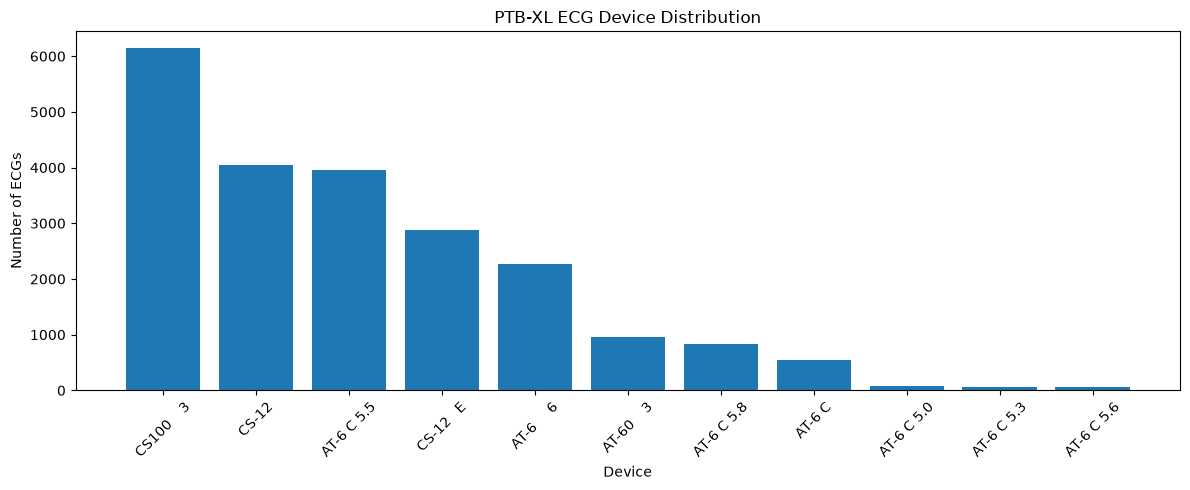

In [43]:
if "device" in ptbxl.columns:

    device_summary = (
        ptbxl["device"]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    device_summary["percentage"] = (
        device_summary["count"] / len(ptbxl) * 100
    ).round(2)

    display(device_summary)

    plt.figure(figsize=(12, 5))

    plt.bar(
        device_summary.index.astype(str),
        device_summary["count"]
    )

    plt.xlabel("Device")
    plt.ylabel("Number of ECGs")
    plt.title("PTB-XL ECG Device Distribution")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [44]:
if "site" in ptbxl.columns:

    site_summary = (
        ptbxl["site"]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    site_summary["percentage"] = (
        site_summary["count"] / len(ptbxl) * 100
    ).round(2)

    display(site_summary.head(30))

,count,percentage
site,,
0.0,8940,40.94
1.0,6296,28.83
2.0,5075,23.24
3.0,611,2.80
4.0,100,0.46
5.0,58,0.27
6.0,46,0.21
8.0,43,0.20
7.0,43,0.20


In [45]:
age_by_split = (
    ptbxl.groupby("split")["age"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .reindex(["train", "val", "test"])
)

display(age_by_split)

,count,mean,std,min,median,max
split,,,,,,
train,17379,59.637091,16.824506,2.0,61.0,95.0
val,2182,60.338222,17.417368,3.0,62.0,95.0
test,2187,60.918610,17.451351,4.0,63.0,94.0


In [46]:
sex_by_split = pd.crosstab(
    ptbxl["split"],
    ptbxl["sex"],
    normalize="index"
) * 100

sex_by_split = sex_by_split.reindex(
    ["train", "val", "test"]
)

display(
    sex_by_split.round(2)
)

sex,0,1
split,,
train,52.20,47.80
val,51.89,48.11
test,51.61,48.39


In [47]:
filename_column = "filename_lr"

if filename_column not in ptbxl.columns:
    filename_column = "filename_hr"

sample_row = ptbxl.iloc[0]

sample_record = sample_row[filename_column]

record_path = DATA_DIR / sample_record

print("Record:")
print(record_path)

signal, fields = wfdb.rdsamp(str(record_path))

print("\nSignal shape:", signal.shape)
print("Sampling frequency:", fields["fs"])
print("Number of channels:", fields["n_sig"])
print("Signal names:", fields["sig_name"])

Record:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\ecg\ptbxl\records100\00000\00001_lr

Signal shape: (1000, 12)
Sampling frequency: 100
Number of channels: 12
Signal names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


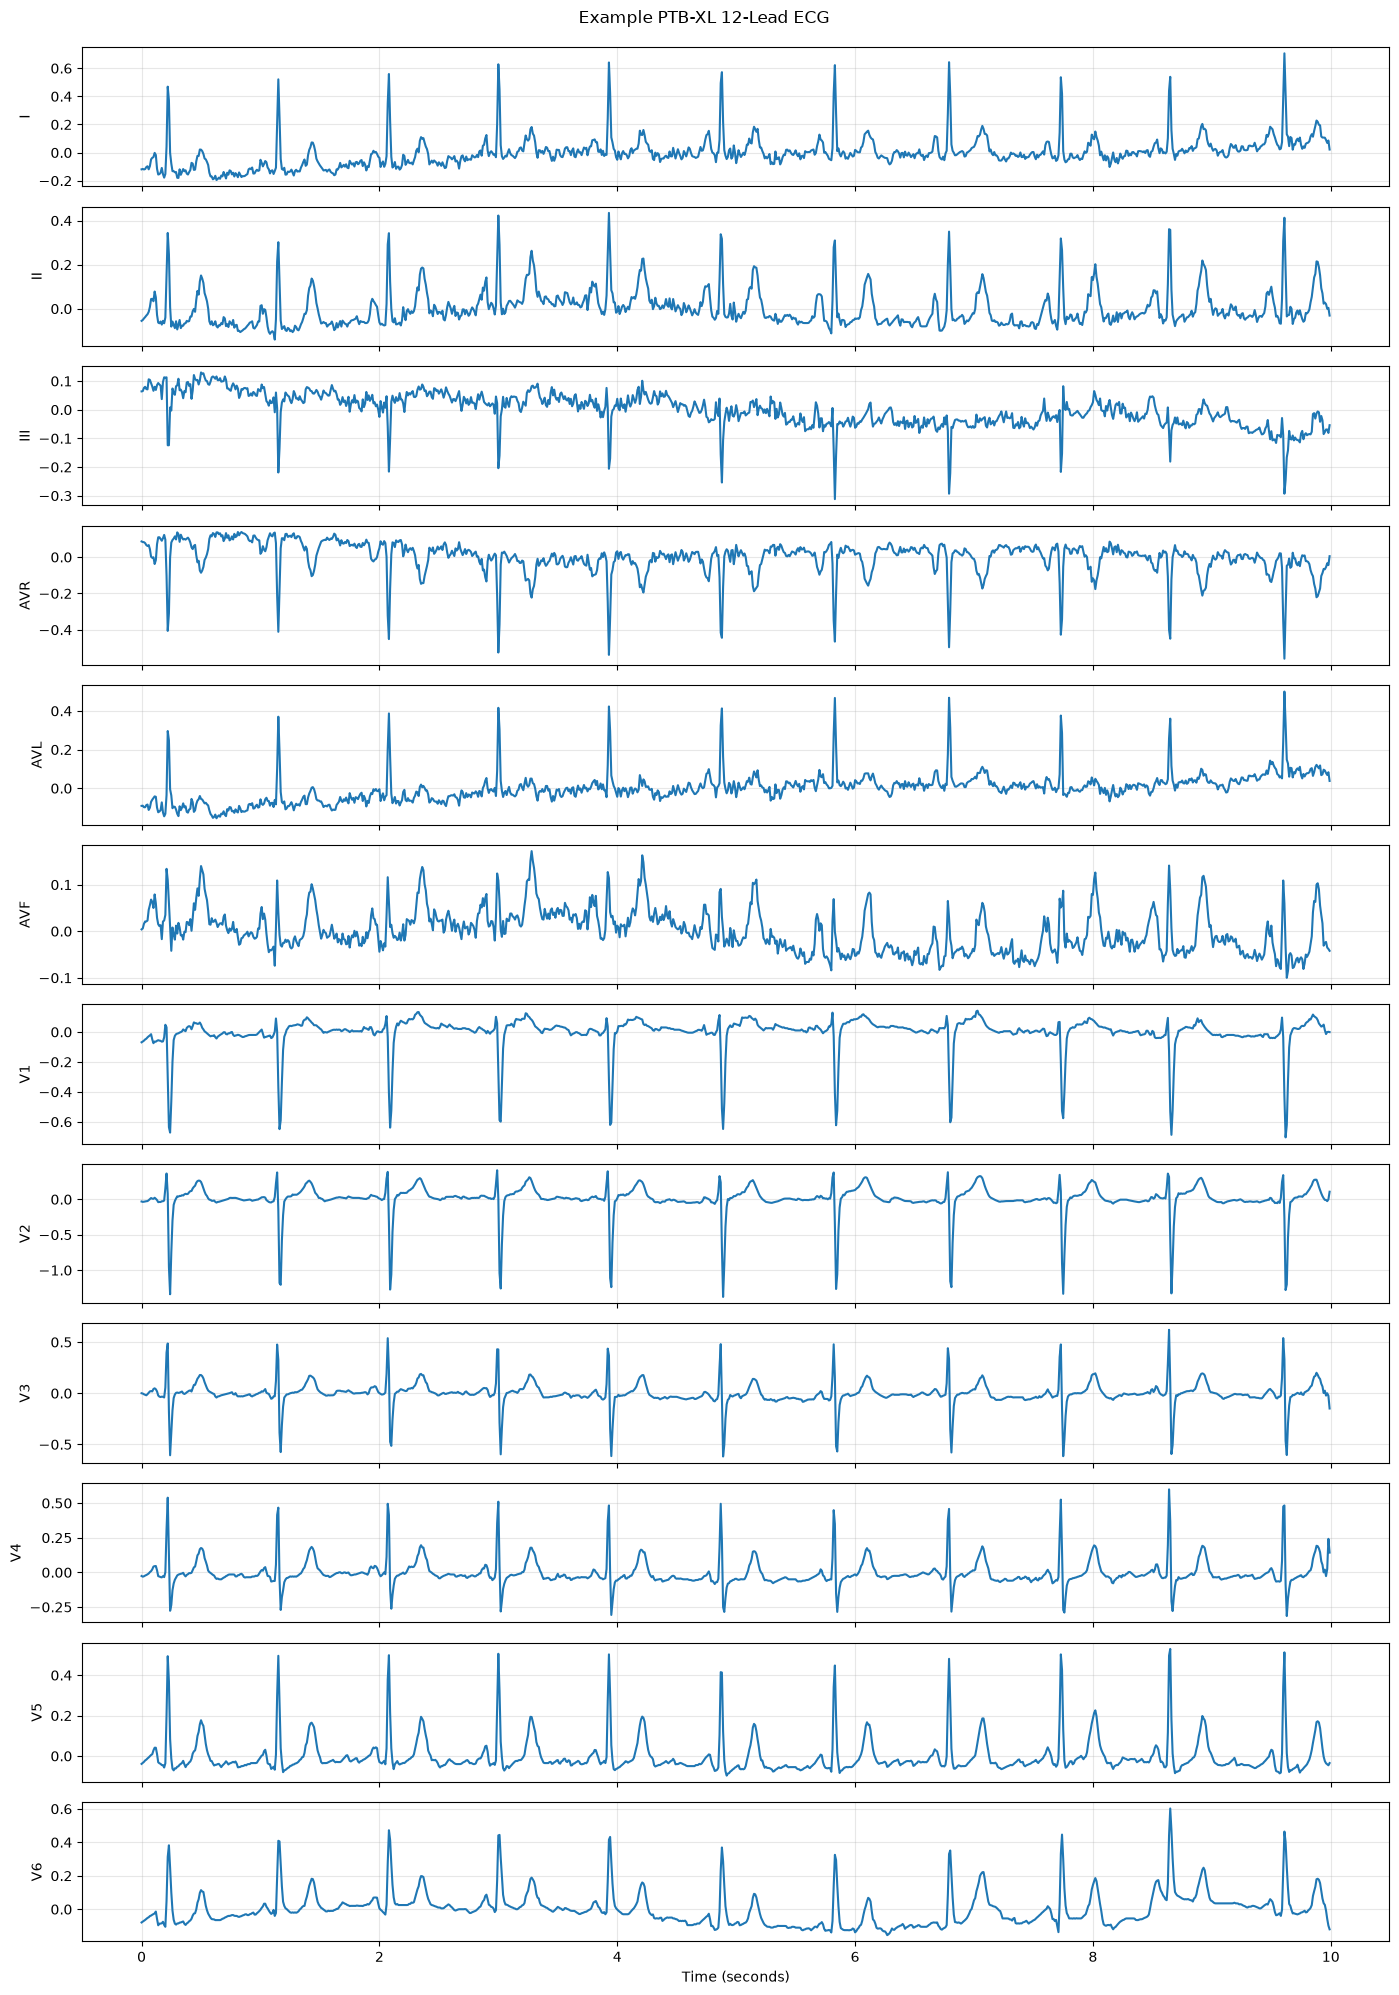

In [48]:
time = np.arange(signal.shape[0]) / fields["fs"]

fig, axes = plt.subplots(
    12,
    1,
    figsize=(14, 20),
    sharex=True
)

for i, lead in enumerate(fields["sig_name"]):

    axes[i].plot(
        time,
        signal[:, i]
    )

    axes[i].set_ylabel(lead)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    "Example PTB-XL 12-Lead ECG",
    y=0.995
)

plt.tight_layout()
plt.show()

In [49]:
RANDOM_SEED = 42
SIGNAL_AUDIT_SAMPLES = 100

rng = np.random.default_rng(RANDOM_SEED)

sample_indices = rng.choice(
    len(ptbxl),
    size=min(SIGNAL_AUDIT_SAMPLES, len(ptbxl)),
    replace=False
)

signal_audit_rows = []

for index in sample_indices:

    row = ptbxl.iloc[index]
    record_path = DATA_DIR / row[filename_column]

    try:

        signal, fields = wfdb.rdsamp(
            str(record_path)
        )

        signal_audit_rows.append({
            "ecg_id": row.name,
            "shape": tuple(signal.shape),
            "sampling_frequency": fields["fs"],
            "n_sig": fields["n_sig"],
            "has_nan": bool(np.isnan(signal).any()),
            "has_inf": bool(np.isinf(signal).any()),
            "all_zero": bool(np.all(signal == 0)),
        })

    except Exception as exc:

        signal_audit_rows.append({
            "ecg_id": row.name,
            "shape": None,
            "sampling_frequency": None,
            "n_sig": None,
            "has_nan": None,
            "has_inf": None,
            "all_zero": None,
            "error": str(exc),
        })

signal_audit = pd.DataFrame(
    signal_audit_rows
)

display(signal_audit)

,ecg_id,shape,sampling_frequency,n_sig,has_nan,has_inf,all_zero
0,9539,"(1000, 12)",100,12,False,False,False
1,20516,"(1000, 12)",100,12,False,False,False
2,14614,"(1000, 12)",100,12,False,False,False
3,10171,"(1000, 12)",100,12,False,False,False
4,9806,"(1000, 12)",100,12,False,False,False
5,16959,"(1000, 12)",100,12,False,False,False
6,3363,"(1000, 12)",100,12,False,False,False
7,7104,"(1000, 12)",100,12,False,False,False
8,3599,"(1000, 12)",100,12,False,False,False
9,15607,"(1000, 12)",100,12,False,False,False


In [50]:
print("Signal audit samples:", len(signal_audit))

print(
    "\nSampling frequencies:"
)

display(
    signal_audit[
        "sampling_frequency"
    ]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

print("\nShapes:")

display(
    signal_audit[
        "shape"
    ]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

print(
    "\nNaN signals:",
    signal_audit["has_nan"].sum()
)

print(
    "Inf signals:",
    signal_audit["has_inf"].sum()
)

print(
    "All-zero signals:",
    signal_audit["all_zero"].sum()
)

signal_audit.to_csv(
    ARTIFACT_DIR / "signal_audit_sample.csv",
    index=False
)

Signal audit samples: 100

Sampling frequencies:


,count
sampling_frequency,
100,100



Shapes:


,count
shape,
"(1000, 12)",100



NaN signals: 0
Inf signals: 0
All-zero signals: 0


In [51]:
EXPECTED_LEADS = [
    "I",
    "II",
    "III",
    "AVR",
    "AVL",
    "AVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
]

actual_leads = list(fields["sig_name"])

print("Expected leads:")
print(EXPECTED_LEADS)

print("\nActual leads:")
print(actual_leads)

print(
    "\nLead order matches expected:",
    actual_leads == EXPECTED_LEADS
)

Expected leads:
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Actual leads:
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Lead order matches expected: True


In [52]:
file_reference_summary = {
    "filename_lr_exists": (
        ptbxl["filename_lr"].notna().sum()
        if "filename_lr" in ptbxl.columns
        else 0
    ),
    "filename_hr_exists": (
        ptbxl["filename_hr"].notna().sum()
        if "filename_hr" in ptbxl.columns
        else 0
    ),
}

display(
    pd.Series(file_reference_summary)
    .rename("count")
    .to_frame()
)

,count
filename_lr_exists,21837
filename_hr_exists,21837


In [53]:
def add_imbalance_metrics(summary):
    result = summary.copy()

    total = len(ptbxl)

    result["positive_count"] = result["count"]

    result["negative_count"] = (
        total - result["positive_count"]
    )

    result["negative_to_positive_ratio"] = (
        result["negative_count"] /
        result["positive_count"].replace(0, np.nan)
    )

    return result


diagnostic_imbalance = add_imbalance_metrics(
    diagnostic_summary
)

rhythm_imbalance = add_imbalance_metrics(
    rhythm_summary
)

print("Diagnostic imbalance:")
display(
    diagnostic_imbalance.round(3)
)

print("\nRhythm imbalance:")
display(
    rhythm_imbalance.round(3)
)

diagnostic_imbalance.to_csv(
    ARTIFACT_DIR / "diagnostic_imbalance.csv"
)

rhythm_imbalance.to_csv(
    ARTIFACT_DIR / "rhythm_imbalance.csv"
)

Diagnostic imbalance:


,count,percentage,positive_count,negative_count,negative_to_positive_ratio
NORM,9528,43.63,9528,12309,1.292
MI,5486,25.12,5486,16351,2.980
STTC,5250,24.04,5250,16587,3.159
CD,4907,22.47,4907,16930,3.450
HYP,2655,12.16,2655,19182,7.225



Rhythm imbalance:


,count,percentage,positive_count,negative_count,negative_to_positive_ratio
SR,16782,76.85,16782,5055,0.301
AFIB,1514,6.93,1514,20323,13.423
STACH,826,3.78,826,21011,25.437
SARRH,772,3.54,772,21065,27.286
SBRAD,637,2.92,637,21200,33.281
PACE,296,1.36,296,21541,72.774
BIGU,82,0.38,82,21755,265.305
AFLT,73,0.33,73,21764,298.137
PSVT,24,0.11,24,21813,908.875


In [54]:
RARE_LABEL_THRESHOLD = 100

rare_diagnostic = diagnostic_summary[
    diagnostic_summary["count"] < RARE_LABEL_THRESHOLD
]

rare_rhythm = rhythm_summary[
    rhythm_summary["count"] < RARE_LABEL_THRESHOLD
]

print("Rare diagnostic labels:")
display(rare_diagnostic)

print("\nRare rhythm labels:")
display(rare_rhythm)

Rare diagnostic labels:


,count,percentage



Rare rhythm labels:


,count,percentage
BIGU,82,0.38
AFLT,73,0.33
PSVT,24,0.11


In [55]:
ptbxl["diagnostic_label_count"] = (
    ptbxl["diagnostic_labels"]
    .apply(len)
)

ptbxl["rhythm_label_count"] = (
    ptbxl["rhythm_labels"]
    .apply(len)
)

label_count_summary = pd.DataFrame({
    "diagnostic_labels_per_ecg": [
        ptbxl["diagnostic_label_count"].mean(),
        ptbxl["diagnostic_label_count"].median(),
        ptbxl["diagnostic_label_count"].max(),
    ],
    "rhythm_labels_per_ecg": [
        ptbxl["rhythm_label_count"].mean(),
        ptbxl["rhythm_label_count"].median(),
        ptbxl["rhythm_label_count"].max(),
    ],
}, index=["mean", "median", "max"])

display(
    label_count_summary.round(3)
)

,diagnostic_labels_per_ecg,rhythm_labels_per_ecg
mean,1.274,0.962
median,1.000,1.000
max,4.000,2.000


In [56]:
print("=" * 70)
print("PTB-XL EDA INTEGRITY CHECK")
print("=" * 70)

checks = {
    "Dataset non-empty":
        len(ptbxl) > 0,

    "Patient IDs available":
        ptbxl["patient_id"].notna().all(),

    "SCP annotations parsed":
        (~ptbxl["scp_codes_parsed"].apply(lambda x: len(x) == 0)).all(),

    "Official folds available":
        ptbxl["strat_fold"].notna().all(),

    "Train split non-empty":
        (ptbxl["split"] == "train").any(),

    "Validation split non-empty":
        (ptbxl["split"] == "val").any(),

    "Test split non-empty":
        (ptbxl["split"] == "test").any(),

    "Train/val patient leakage absent":
        len(train_val_overlap) == 0,

    "Train/test patient leakage absent":
        len(train_test_overlap) == 0,

    "Val/test patient leakage absent":
        len(val_test_overlap) == 0,
}

for name, passed in checks.items():
    print(
        f"[{'PASS' if passed else 'FAIL'}] {name}"
    )

if not all(checks.values()):
    raise AssertionError(
        "One or more critical EDA integrity checks failed."
    )

print("\nAll critical EDA integrity checks passed.")

PTB-XL EDA INTEGRITY CHECK
[PASS] Dataset non-empty
[PASS] Patient IDs available
[PASS] SCP annotations parsed
[PASS] Official folds available
[PASS] Train split non-empty
[PASS] Validation split non-empty
[PASS] Test split non-empty
[PASS] Train/val patient leakage absent
[PASS] Train/test patient leakage absent
[PASS] Val/test patient leakage absent

All critical EDA integrity checks passed.


In [57]:
# Convert set-valued columns to JSON strings so the dataframe
# can be saved as CSV cleanly.

eda_metadata = ptbxl.copy()

eda_metadata["diagnostic_labels"] = (
    eda_metadata["diagnostic_labels"]
    .apply(lambda x: json.dumps(sorted(x)))
)

eda_metadata["rhythm_labels"] = (
    eda_metadata["rhythm_labels"]
    .apply(lambda x: json.dumps(sorted(x)))
)

eda_metadata["scp_codes_parsed"] = (
    eda_metadata["scp_codes_parsed"]
    .apply(lambda x: json.dumps(x))
)

output_file = (
    ARTIFACT_DIR /
    "ptbxl_eda_metadata.csv"
)

eda_metadata.to_csv(
    output_file,
    index=True
)

print("Saved:", output_file)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\ptbxl\ptbxl_eda_metadata.csv


In [58]:
eda_config = {
    "dataset": "PTB-XL",
    "diagnostic_labels": DIAGNOSTIC_LABELS,
    "rhythm_labels": RHYTHM_LABELS,
    "train_folds": TRAIN_FOLDS,
    "validation_folds": VAL_FOLDS,
    "test_folds": TEST_FOLDS,
    "random_seed": RANDOM_SEED,
    "signal_audit_samples": SIGNAL_AUDIT_SAMPLES,
    "filename_column_inspected": filename_column,
}

config_file = ARTIFACT_DIR / "eda_config.json"

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(
        eda_config,
        f,
        indent=2
    )

print("Saved:", config_file)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\ptbxl\eda_config.json


In [59]:
print("=" * 80)
print("PTB-XL FINAL EDA SUMMARY")
print("=" * 80)

print(f"\nTotal ECG records : {len(ptbxl):,}")
print(f"Unique patients   : {ptbxl['patient_id'].nunique():,}")

print("\nSplit sizes:")
display(split_summary)

print("\nDiagnostic labels:")
display(diagnostic_summary)

print("\nRhythm labels:")
display(rhythm_summary)

print("\nPatient leakage:")
print("Train ∩ Val :", len(train_val_overlap))
print("Train ∩ Test:", len(train_test_overlap))
print("Val ∩ Test  :", len(val_test_overlap))

print("\nSignal audit:")
print(
    "NaN signals:",
    int(signal_audit["has_nan"].fillna(False).sum())
)
print(
    "Inf signals:",
    int(signal_audit["has_inf"].fillna(False).sum())
)
print(
    "All-zero signals:",
    int(signal_audit["all_zero"].fillna(False).sum())
)

print("\nArtifacts saved to:")
print(ARTIFACT_DIR)

PTB-XL FINAL EDA SUMMARY

Total ECG records : 21,837
Unique patients   : 18,885

Split sizes:


,ecg_count,percentage
split,,
train,17441,79.87
val,2193,10.04
test,2203,10.09



Diagnostic labels:


,count,percentage
NORM,9528,43.63
MI,5486,25.12
STTC,5250,24.04
CD,4907,22.47
HYP,2655,12.16



Rhythm labels:


,count,percentage
SR,16782,76.85
AFIB,1514,6.93
STACH,826,3.78
SARRH,772,3.54
SBRAD,637,2.92
PACE,296,1.36
BIGU,82,0.38
AFLT,73,0.33
PSVT,24,0.11



Patient leakage:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Signal audit:
NaN signals: 0
Inf signals: 0
All-zero signals: 0

Artifacts saved to:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\ptbxl
